In [9]:
import rasterio
from rasterio.plot import show
import matplotlib.pyplot as plt

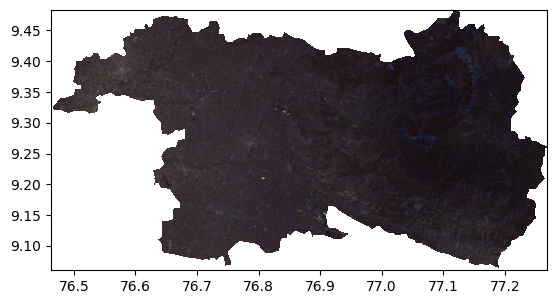

<Axes: >

In [4]:
img = rasterio.open(r"C:\Users\VIKASH KUMAR\Downloads\Landsat_2014_2015_Harmonized.tif")
show(img)

In [ ]:
full_img = img.read()
print(full_img)

In [7]:
num_bands = img.count
print(num_bands)

6


In [8]:
img_band1 = img.read(1)
img_band2 = img.read(2)
img_band3 = img.read(3)

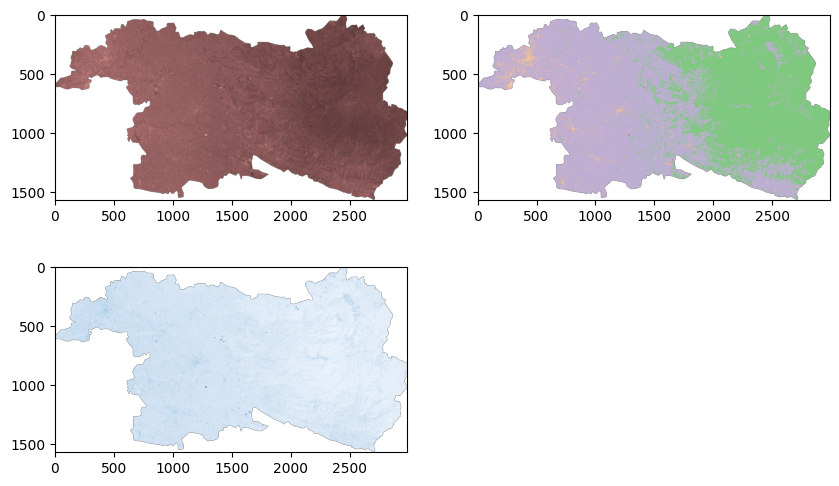

In [12]:
fig = plt.figure(figsize=(10,6))
ax1 = fig.add_subplot(2,2,1)
ax1.imshow(img_band1, cmap='pink')
ax2 = fig.add_subplot(2,2,2)
ax2.imshow(img_band2, cmap='Accent')
ax3 = fig.add_subplot(2,2,3)
ax3.imshow(img_band3, cmap='Blues')

In [13]:
print(img.crs)

GEOGCS["WGS 84",DATUM["World Geodetic System 1984",SPHEROID["WGS 84",6378137,298.257223563]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST]]


In [15]:
print(img.meta)

{'driver': 'GTiff', 'dtype': 'float64', 'nodata': None, 'width': 2989, 'height': 1569, 'count': 6, 'crs': CRS.from_wkt('GEOGCS["WGS 84",DATUM["World Geodetic System 1984",SPHEROID["WGS 84",6378137,298.257223563]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST]]'), 'transform': Affine(0.00026949458523585647, 0.0, 76.46235119604337,
       0.0, -0.00026949458523585647, 9.483244959864553)}


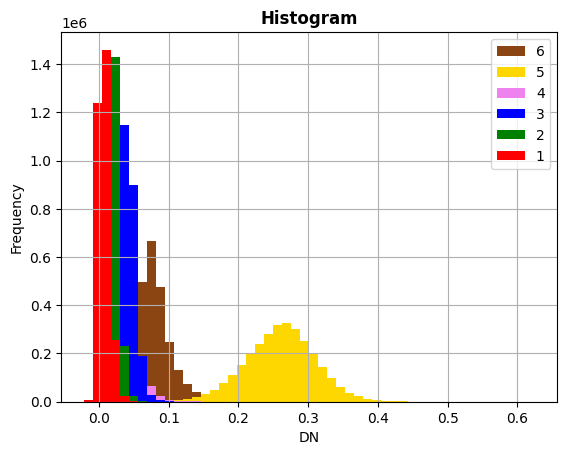

In [19]:
rasterio.plot.show_hist(full_img, bins=50, histtype='stepfilled')

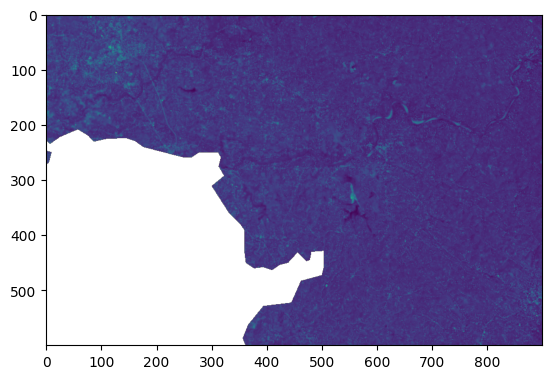

In [24]:
clipped_img = full_img[:, 300:900, 300:1200]
plt.imshow(clipped_img[0,:,:])



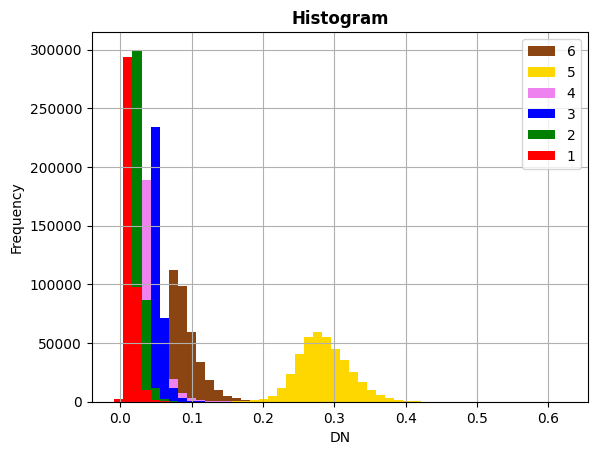

In [25]:
rasterio.plot.show_hist(clipped_img, bins=50, histtype='stepfilled')

In [26]:
import numpy as np

In [32]:
red_clipped = clipped_img[2].astype('f4')
nir_clipped = clipped_img[3].astype('f4')

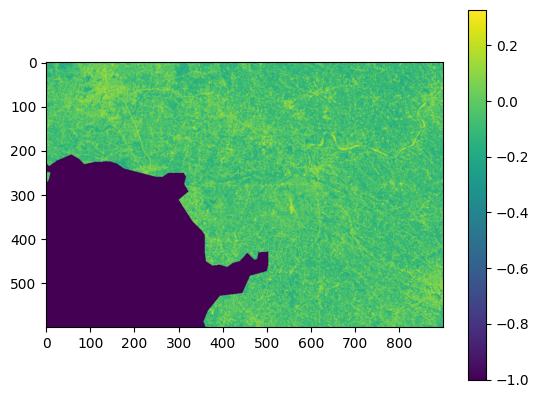

In [33]:
ndvi_clipped2 = np.divide(np.subtract(nir_clipped,red_clipped), np.add(nir_clipped,red_clipped))
ndvi_clipped3 = np.nan_to_num(ndvi_clipped2, nan = -1)
plt.imshow(ndvi_clipped3, cmap='viridis')
plt.colorbar()